# Análisis profundo de la planta dada

## Planta bajo estudio

$$
G_p(s)=\frac{s+40}{s^3+60s^2+875s}
$$

o, en forma factorizada:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

Este notebook analiza exclusivamente la planta original, sin partir todavía del compensador.  
El objetivo es desmenuzar su estructura, comprender su dinámica, identificar defectos, proponer mejoras posibles y luego interpretar críticamente por qué el TP original solicita valores como:

$$
\zeta = 0.628
$$

$$
\omega_n = 21.324 \; rad/s
$$

$$
K_v = 3
$$

## Índice

1. Objetivo del análisis  
2. Definición de la planta  
3. Factorización e interpretación de polos y cero  
4. Tipo del sistema  
5. Ganancia de baja frecuencia y constante de velocidad  
6. Estabilidad en lazo abierto  
7. Respuesta al impulso de la planta  
8. Respuesta al escalón de la planta en lazo abierto  
9. Planta con realimentación unitaria  
10. Lazo cerrado con ganancia variable  
11. Interpretación del lugar geométrico de las raíces  
12. Análisis de Bode  
13. Análisis de Nyquist  
14. Sensibilidad a entradas: escalón, rampa, parábola y senoidal  
15. Defectos dinámicos de la planta  
16. Qué se puede mejorar y por qué  
17. Estrategias de compensación posibles  
18. Relación con los requerimientos originales del TP  
19. Para qué sirve pedir $(\zeta$), $(\omega_n$) y $(K_v$)  
20. Conclusión técnica

# 1. Objetivo del análisis

Antes de diseñar un compensador conviene comprender la planta.

Una planta no debe tratarse como una expresión algebraica aislada. Cada polo, cero, integrador y pendiente de Bode expresa una propiedad dinámica.

Este análisis busca responder:

- ¿Qué tipo de sistema representa esta planta?
- ¿Qué indican sus polos?
- ¿Qué indica su cero?
- ¿Qué comportamiento tendrá ante escalón, rampa y perturbaciones?
- ¿Qué defectos tiene?
- ¿Qué se puede mejorar?
- ¿Qué sentido tienen las especificaciones originales del TP?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import math
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# 2. Definición de la planta

La planta es:

$$
G_p(s)=\frac{s+40}{s^3+60s^2+875s}
$$

El denominador puede escribirse como:

$$
s^3+60s^2+875s=s(s^2+60s+875)
$$

y:

$$
s^2+60s+875=(s+25)(s+35)
$$

Por lo tanto:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

In [2]:
num_p = np.array([1, 40], dtype=float)
den_p = np.array([1, 60, 875, 0], dtype=float)

Gp = signal.TransferFunction(num_p, den_p)

poles_p = np.roots(den_p)
zeros_p = np.roots(num_p)

print("Numerador:", num_p)
print("Denominador:", den_p)
print("Polos:", poles_p)
print("Ceros:", zeros_p)

Numerador: [ 1. 40.]
Denominador: [  1.  60. 875.   0.]
Polos: [-35. -25.   0.]
Ceros: [-40.]


# 3. Factorización e interpretación de polos y cero

La planta tiene:

$$
p_1=0
$$

$$
p_2=-25
$$

$$
p_3=-35
$$

y un cero:

$$
z_1=-40
$$

## Interpretación

### Polo en el origen

El polo en el origen representa un integrador:

$$
\frac{1}{s}
$$

Esto implica memoria acumulativa. En términos físicos, puede representar una variable de posición obtenida por integración de velocidad, carga acumulada, nivel acumulado, desplazamiento, etc.

### Polos reales negativos

Los polos en $(-25$) y $(-35$) son modos rápidos y estables.

Sus constantes de tiempo aproximadas son:

$$
\tau_1=\frac{1}{25}=0.04s
$$

$$
\tau_2=\frac{1}{35}=0.0286s
$$

Son dinámicas rápidas.

### Ceros

El cero en $(-40$) también está en una zona rápida. Su presencia modifica la forma de la respuesta transitoria y la pendiente de fase, pero no introduce inestabilidad porque está en el semiplano izquierdo.

In [3]:
for p in poles_p:
    if abs(p) > 1e-12:
        print(f"Polo {p:.4g} -> tau = {-1/p:.6f} s")
    else:
        print(f"Polo {p:.4g} -> integrador, tau infinita")

for z in zeros_p:
    print(f"Cero {z:.4g} -> tau cero equivalente = {-1/z:.6f} s")

Polo -35 -> tau = 0.028571 s
Polo -25 -> tau = 0.040000 s
Polo 0 -> integrador, tau infinita
Cero -40 -> tau cero equivalente = 0.025000 s


# 4. Tipo del sistema

El tipo de un sistema en control clásico se define por la cantidad de integradores puros en el lazo abierto.

La planta posee un polo en el origen:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

Por lo tanto, es una planta de tipo 1.

## Consecuencia

Con realimentación unitaria:

- error estacionario ante escalón: cero;
- error estacionario ante rampa: finito;
- error estacionario ante parábola: infinito.

Esto ya anticipa por qué una consigna puede pedir una constante \(K_v\).

# 5. Ganancia de baja frecuencia y constante de velocidad

Para una planta tipo 1, la constante de velocidad es:

$$
K_v=\lim_{s\to 0}sG(s)
$$

Para la planta sin ganancia adicional:

$$
K_v=\lim_{s\to 0}s\frac{s+40}{s(s+25)(s+35)}
$$

$$
K_v=\frac{40}{25\cdot35}
$$

$$
K_v=\frac{40}{875}=0.045714
$$

Esto es bajo. Por lo tanto, si la planta debe seguir una rampa, su error estacionario será grande:

$$
e_{ss,rampa}=\frac{1}{K_v}
$$

In [4]:
Kv_plant = 40/(25*35)
ess_ramp_plant = 1/Kv_plant

print("Kv de la planta sin ganancia:", Kv_plant)
print("Error estacionario ante rampa:", ess_ramp_plant)

Kv de la planta sin ganancia: 0.045714285714285714
Error estacionario ante rampa: 21.875


# 6. Estabilidad en lazo abierto

En lazo abierto, la planta posee un polo en el origen.  
Esto significa que no es asintóticamente estable en sentido estricto, porque un polo en \(s=0\) no decae.

Sin embargo, no tiene polos en el semiplano derecho.

Por eso puede considerarse marginal por el integrador y potencialmente estabilizable mediante realimentación.

In [5]:
print("Polos de la planta:")
print(poles_p)

stable_strict = np.all(np.real(poles_p) < 0)
right_half_plane = np.any(np.real(poles_p) > 0)

print("Asintóticamente estable en lazo abierto:", stable_strict)
print("Tiene polos en semiplano derecho:", right_half_plane)

Polos de la planta:
[-35. -25.   0.]
Asintóticamente estable en lazo abierto: False
Tiene polos en semiplano derecho: False


# 7. Respuesta al impulso de la planta

La respuesta al impulso permite observar la respuesta natural de la planta.

Como existe un integrador, la respuesta al impulso tiende a un valor constante no nulo. Esto es coherente con la presencia de un polo en el origen.

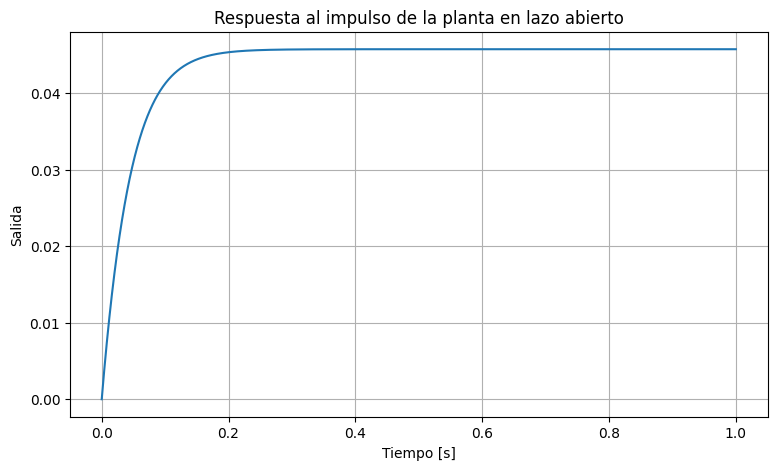

Valor final aproximado de la respuesta al impulso: 0.04571428571345266


In [6]:
t = np.linspace(0, 1, 2000)
t_imp, y_imp = signal.impulse(Gp, T=t)

plt.figure()
plt.plot(t_imp, y_imp)
plt.title("Respuesta al impulso de la planta en lazo abierto")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.show()

print("Valor final aproximado de la respuesta al impulso:", y_imp[-1])

# 8. Respuesta al escalón de la planta en lazo abierto

Ante un escalón, una planta con integrador tiende a crecer sin límite o a aproximarse a una rampa.

Esto no debe confundirse con la respuesta al escalón del sistema realimentado.  
La planta sola no tiene corrección de error: simplemente integra.

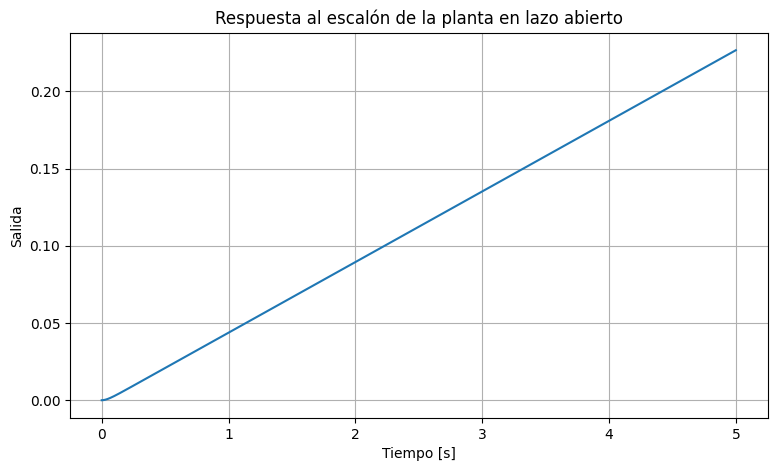

Valor final aproximado en ventana simulada: 0.2265795918367471


In [7]:
t = np.linspace(0, 5, 3000)
t_step_ol, y_step_ol = signal.step(Gp, T=t)

plt.figure()
plt.plot(t_step_ol, y_step_ol)
plt.title("Respuesta al escalón de la planta en lazo abierto")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.show()

print("Valor final aproximado en ventana simulada:", y_step_ol[-1])

# 9. Planta con realimentación unitaria

Para estudiar comportamiento de servo o regulación, cerramos lazo con realimentación unitaria:

$$
T(s)=\frac{G_p(s)}{1+G_p(s)}
$$

Si:

$$
G_p(s)=\frac{N(s)}{D(s)}
$$

entonces:

$$
T(s)=\frac{N(s)}{D(s)+N(s)}
$$

In [8]:
def closed_loop(num, den, K=1):
    num_ol = K*np.array(num, dtype=float)
    den_ol = np.array(den, dtype=float)
    den_cl = np.polyadd(den_ol, num_ol)
    num_cl = num_ol
    return signal.TransferFunction(num_cl, den_cl), num_cl, den_cl

T1, num_T1, den_T1 = closed_loop(num_p, den_p, K=1)

print("Lazo cerrado con K=1")
print("Numerador:", num_T1)
print("Denominador:", den_T1)
print("Polos:", np.roots(den_T1))

Lazo cerrado con K=1
Numerador: [ 1. 40.]
Denominador: [  1.  60. 876.  40.]
Polos: [-35.01421909 -24.93997521  -0.0458057 ]


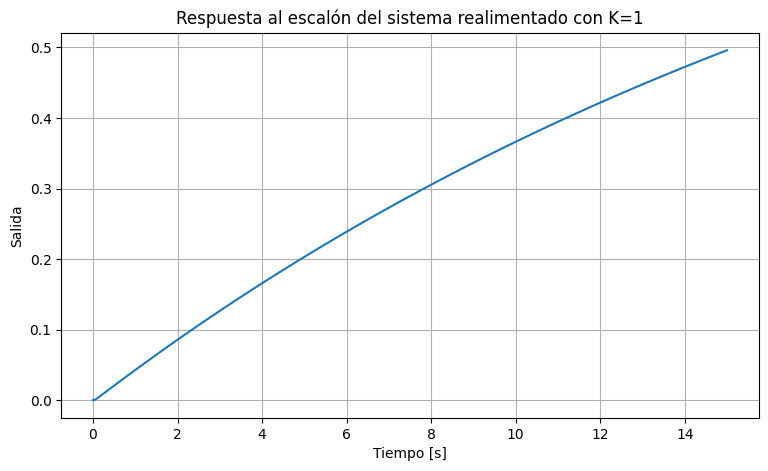

In [9]:
t = np.linspace(0, 15, 3000)
t_cl, y_cl = signal.step(T1, T=t)

plt.figure()
plt.plot(t_cl, y_cl)
plt.title("Respuesta al escalón del sistema realimentado con K=1")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.show()

# 10. Lazo cerrado con ganancia variable

Una acción básica de mejora es agregar una ganancia proporcional \(K\):

$$
G_{OL}(s)=KG_p(s)
$$

Esto cambia la ecuación característica:

$$
D(s)+KN(s)=0
$$

La ganancia afecta:

- velocidad de respuesta;
- amortiguamiento;
- error de rampa;
- márgenes de estabilidad.

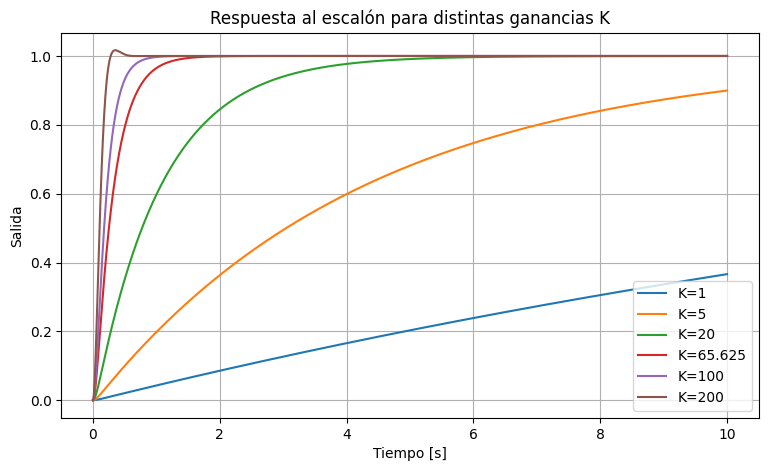


K = 1
Polos: [-35.01421909 -24.93997521  -0.0458057 ]
Kv = 0.045714285714285714
{'valor_final': np.float64(0.36622128649490476), 'sobrepico_%': 0, 'tiempo_subida_10_90': np.float64(7.914478619654914), 'tiempo_establecimiento_2%': np.float64(9.749937484371092)}

K = 5
Polos: [-35.06980393 -24.69930244  -0.23089364]
Kv = 0.22857142857142856
{'valor_final': np.float64(0.8996135168286981), 'sobrepico_%': 0, 'tiempo_subida_10_90': np.float64(6.776694173543386), 'tiempo_establecimiento_2%': np.float64(9.287321830457614)}

K = 20
Polos: [-35.26188073 -23.78423582  -0.95388345]
Kv = 0.9142857142857143
{'valor_final': np.float64(0.9999247439582395), 'sobrepico_%': 0, 'tiempo_subida_10_90': np.float64(2.3030757689422354), 'tiempo_establecimiento_2%': np.float64(4.146036509127281)}

K = 65.625
Polos: [-35.73072311 -20.72435688  -3.54492001]
Kv = 3.0
{'valor_final': np.float64(0.9999999999999941), 'sobrepico_%': np.float64(2.2204460492503263e-14), 'tiempo_subida_10_90': np.float64(0.6376594148537

In [10]:
def step_info(t, y, tol=0.02):
    y = np.asarray(y)
    t = np.asarray(t)
    yf = y[-1]
    yp = np.max(y)
    Mp = np.nan if abs(yf) < 1e-12 else max(0, (yp-yf)/abs(yf)*100)

    band = tol*max(abs(yf), 1e-12)
    outside = np.where(np.abs(y-yf) > band)[0]
    ts = t[outside[-1]+1] if len(outside) and outside[-1]+1 < len(t) else t[0]

    def first_cross(level):
        idx = np.where(y >= level)[0]
        return t[idx[0]] if len(idx) else np.nan

    tr = first_cross(0.9*yf) - first_cross(0.1*yf)
    return {"valor_final": yf, "sobrepico_%": Mp, "tiempo_subida_10_90": tr, "tiempo_establecimiento_2%": ts}

Ks = [1, 5, 20, 65.625, 100, 200]
t = np.linspace(0, 10, 4000)

plt.figure()
for K in Ks:
    T, _, denT = closed_loop(num_p, den_p, K=K)
    tout, yout = signal.step(T, T=t)
    plt.plot(tout, yout, label=f"K={K:g}")

plt.title("Respuesta al escalón para distintas ganancias K")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

for K in Ks:
    T, _, denT = closed_loop(num_p, den_p, K=K)
    poles = np.roots(denT)
    tout, yout = signal.step(T, T=t)
    print("\nK =", K)
    print("Polos:", poles)
    print("Kv =", K*Kv_plant)
    print(step_info(tout, yout))

# 11. Interpretación del lugar geométrico de las raíces

El lugar geométrico de las raíces muestra cómo se desplazan los polos de lazo cerrado al variar la ganancia $(K$).

Para esta planta:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

hay tres polos y un cero.

El root locus ayuda a observar si, solamente con ganancia proporcional, se puede ubicar la dinámica en zonas deseadas.

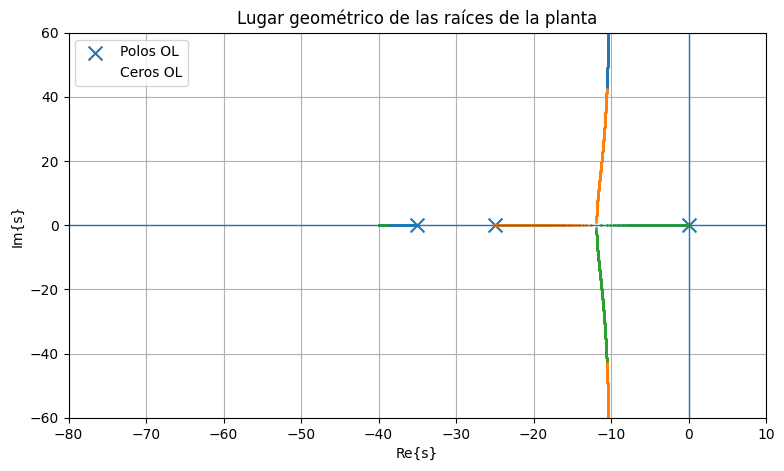

In [11]:
def root_locus(num, den, k_values=None, title="Root locus"):
    if k_values is None:
        k_values = np.logspace(-3, 5, 2000)
    roots = []
    for K in k_values:
        roots.append(np.roots(np.polyadd(den, K*num)))
    roots = np.array(roots)

    plt.figure()
    for i in range(roots.shape[1]):
        plt.plot(np.real(roots[:, i]), np.imag(roots[:, i]), ".", markersize=2)

    poles = np.roots(den)
    zeros = np.roots(num)
    plt.scatter(np.real(poles), np.imag(poles), marker="x", s=100, label="Polos OL")
    plt.scatter(np.real(zeros), np.imag(zeros), marker="o", facecolors="none", s=100, label="Ceros OL")
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Re{s}")
    plt.ylabel("Im{s}")
    plt.legend()
    plt.xlim(-80, 10)
    plt.ylim(-60, 60)
    plt.show()

root_locus(num_p, den_p, title="Lugar geométrico de las raíces de la planta")

# 12. Análisis de Bode

El diagrama de Bode permite observar:

- comportamiento de baja frecuencia;
- pendiente por integrador;
- efecto de polos y cero;
- fase disponible;
- posible margen de estabilidad.

La planta tiene:

- un integrador: aporta \(-20\) dB/década y \(-90^\circ\);
- polos en 25 y 35 rad/s;
- cero en 40 rad/s.

Los polos rápidos y el cero están relativamente agrupados.

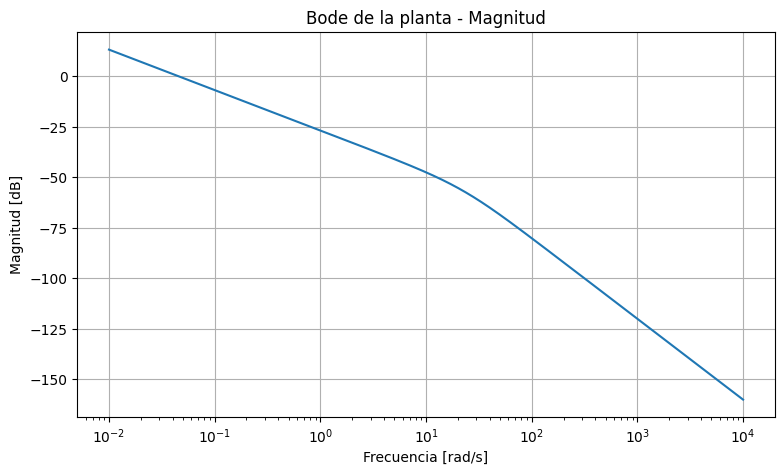

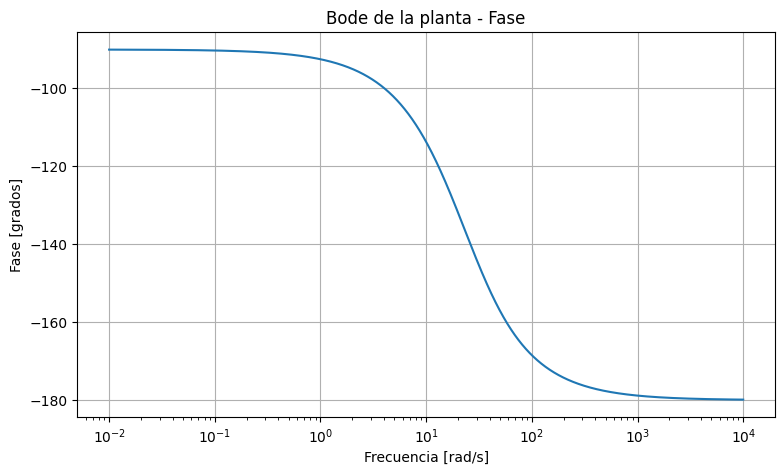

In [12]:
w = np.logspace(-2, 4, 4000)
w, mag, phase = signal.bode(Gp, w=w)

plt.figure()
plt.semilogx(w, mag)
plt.title("Bode de la planta - Magnitud")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.show()

plt.figure()
plt.semilogx(w, phase)
plt.title("Bode de la planta - Fase")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [grados]")
plt.show()

# 13. Análisis de Nyquist

El diagrama de Nyquist permite evaluar estabilidad relativa en lazo cerrado.

La planta no tiene polos en el semiplano derecho, pero sí un integrador.  
La proximidad al punto crítico \(-1+j0\) dependerá de la ganancia aplicada.

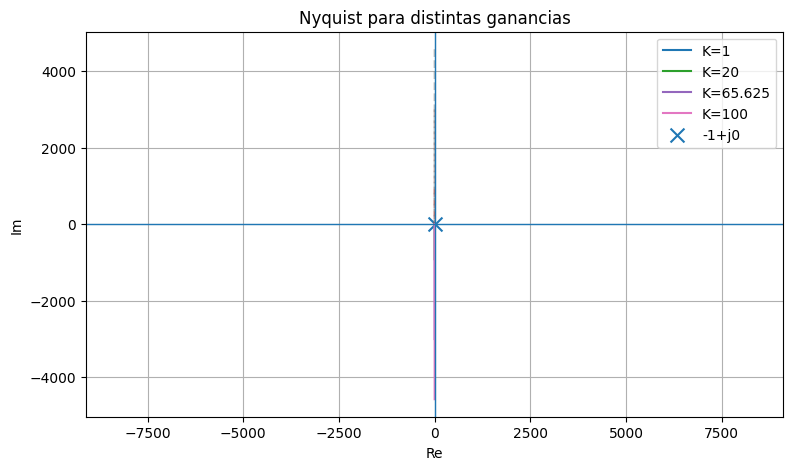

In [13]:
def nyquist(num, den, K=1, label=""):
    w = np.logspace(-3, 4, 5000)
    s = 1j*w
    H = K*np.polyval(num, s)/np.polyval(den, s)
    plt.plot(np.real(H), np.imag(H), label=label)
    plt.plot(np.real(H), -np.imag(H), linestyle="--", alpha=0.5)

plt.figure()
for K in [1, 20, 65.625, 100]:
    nyquist(num_p, den_p, K=K, label=f"K={K:g}")
plt.scatter([-1], [0], marker="x", s=100, label="-1+j0")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("Nyquist para distintas ganancias")
plt.xlabel("Re")
plt.ylabel("Im")
plt.legend()
plt.axis("equal")
plt.show()

# 14. Sensibilidad a entradas: escalón, rampa, parábola y senoidal

Como la planta realimentada es tipo 1, el análisis debe incluir entradas distintas del escalón.

Esto es clave: un sistema puede responder bien al escalón y aun así tener mal seguimiento de rampas.

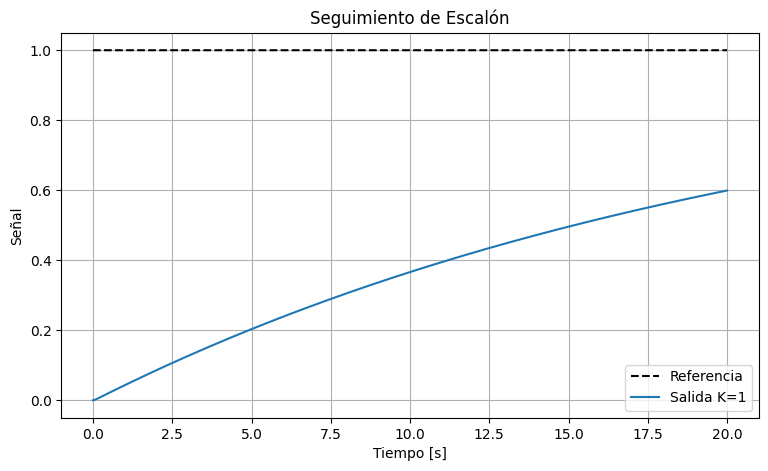

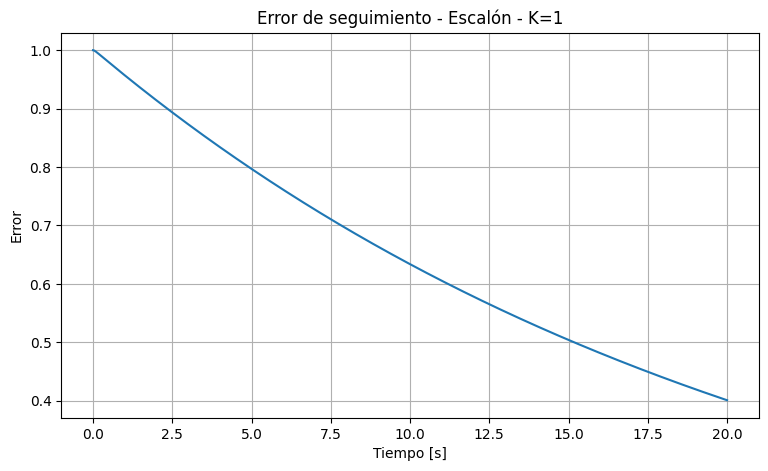

Escalón - error final aproximado: 0.4008722733901513


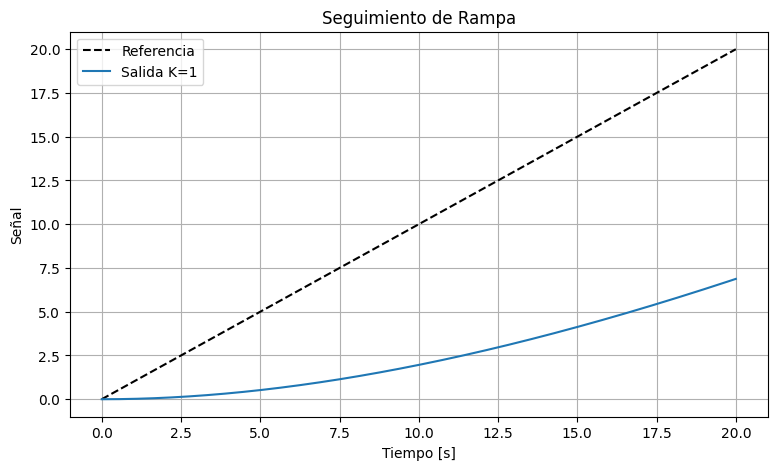

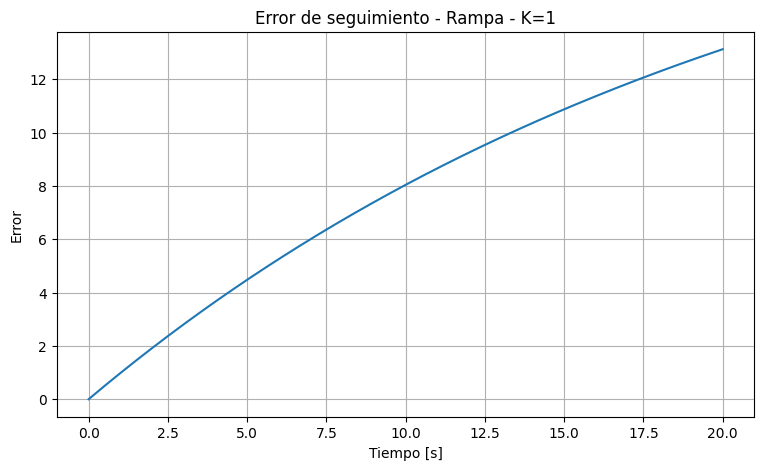

Rampa - error final aproximado: 13.123419538306916


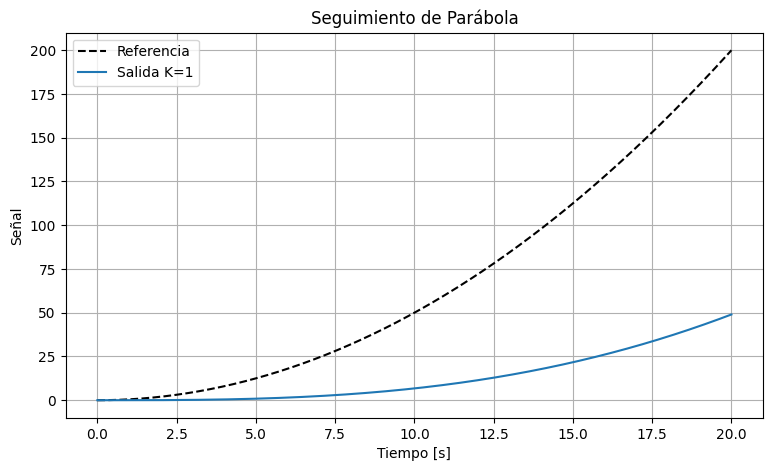

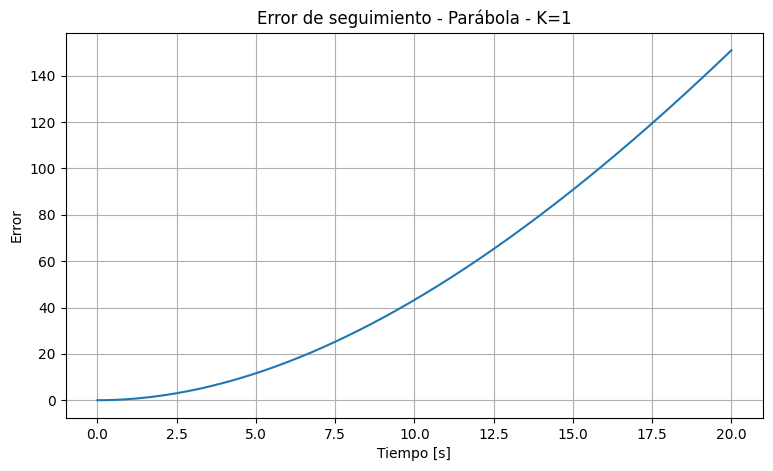

Parábola - error final aproximado: 150.99626150805682


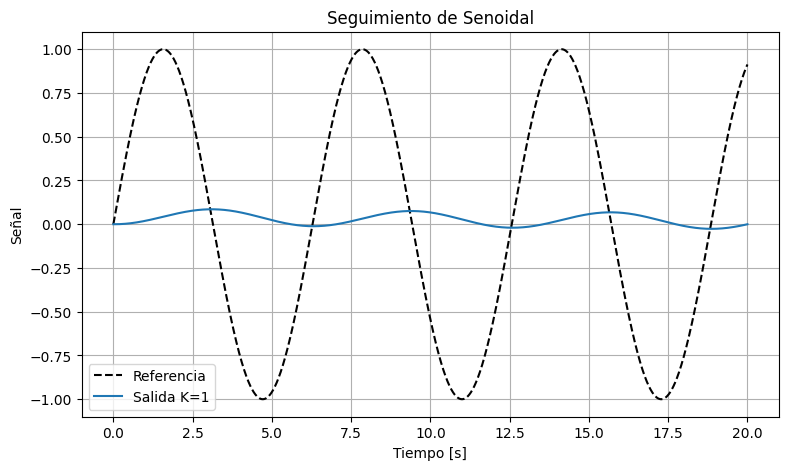

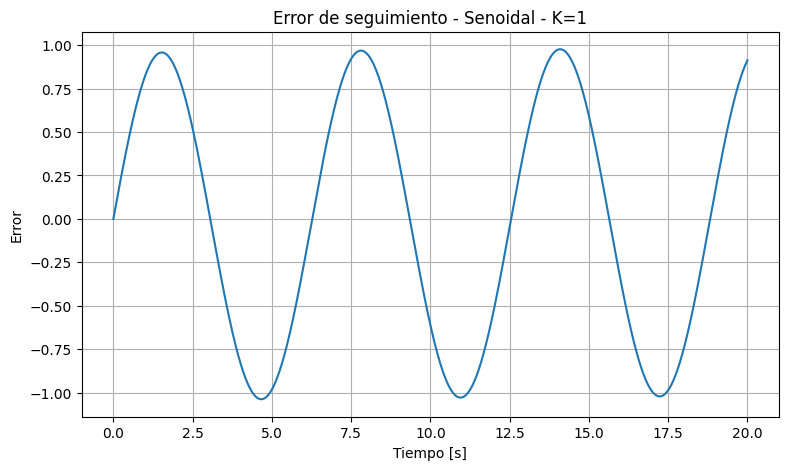

Senoidal - error final aproximado: 0.9131881697582719


In [14]:
def simulate_tracking(Tsys, t, r):
    tout, y, x = signal.lsim(Tsys, U=r, T=t)
    return y, r-y

def compare_inputs(K):
    T, _, _ = closed_loop(num_p, den_p, K=K)

    t = np.linspace(0, 20, 4000)
    inputs = {
        "Escalón": np.ones_like(t),
        "Rampa": t,
        "Parábola": 0.5*t**2,
        "Senoidal": np.sin(t),
    }

    for name, r in inputs.items():
        y, e = simulate_tracking(T, t, r)

        plt.figure()
        plt.plot(t, r, "k--", label="Referencia")
        plt.plot(t, y, label=f"Salida K={K:g}")
        plt.title(f"Seguimiento de {name}")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Señal")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(t, e)
        plt.title(f"Error de seguimiento - {name} - K={K:g}")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Error")
        plt.show()

        print(name, "- error final aproximado:", e[-1])

compare_inputs(K=1)

# 15. Defectos dinámicos de la planta

A partir del análisis anterior, se identifican los siguientes defectos o limitaciones.

## 15.1 Baja constante de velocidad natural

La planta sin ganancia tiene:

$$
K_v=0.0457
$$

Esto produce error grande ante rampa:

$$
e_{ss,rampa}=21.875
$$

Por lo tanto, la planta no es buena para seguimiento de referencia de velocidad si no se ajusta la ganancia o no se compensa.

## 15.2 Integrador en lazo abierto

El integrador permite error nulo ante escalón en lazo cerrado, pero también introduce fase negativa y puede comprometer estabilidad relativa al aumentar ganancia.

## 15.3 Polos rápidos agrupados

Los polos $(-25$) y $(-35$), junto con el cero $(-40$), están en una región de frecuencia alta. Esto genera una dinámica rápida adicional y una modificación de fase concentrada.

## 15.4 La ganancia proporcional no permite elegir libremente todos los requisitos

Con solo $(K$), se puede modificar una dimensión principal de diseño, pero no se puede fijar simultáneamente:

- amortiguamiento;
- frecuencia natural;
- constante de velocidad;
- margen de fase;
- respuesta transitoria;
- rechazo de perturbaciones.

## 15.5 La especificación de segundo orden puede no representar el sistema completo

La planta es de tercer orden. Al compensarla puede pasar a cuarto orden. Por lo tanto, hablar de $(\zeta$) y $(\omega_n$) requiere asumir dominancia de un par de polos.

# 16. Qué se puede mejorar y por qué

## 16.1 Mejorar error ante rampa

Se puede aumentar \(K_v\) mediante:

- aumento de ganancia;
- compensador de atraso;
- acción integral adicional, aunque esto cambiaría el tipo del sistema.

Pero aumentar ganancia puede reducir margen de estabilidad.

## 16.2 Mejorar amortiguamiento

Se puede usar un compensador de adelanto para aportar fase positiva y mejorar estabilidad relativa.

## 16.3 Mejorar rapidez

Se puede desplazar la frecuencia de cruce hacia valores mayores, pero esto puede aumentar sensibilidad al ruido.

## 16.4 Mejorar robustez

Se debe evitar operar con márgenes pequeños. Para ello se puede:

- agregar adelanto;
- limitar ancho de banda;
- verificar Bode y Nyquist;
- analizar sensibilidad.

## 16.5 Mejorar seguimiento de trayectorias

Si el sistema debe seguir rampas o trayectorias suaves, conviene diseñar considerando:

- \(K_v\);
- entrada rampa;
- perfiles de referencia suaves;
- limitaciones físicas del actuador.

# 17. Estrategias de compensación posibles

## 17.1 Ganancia proporcional

$$
G_c(s)=K
$$

Simple, pero limitada.

## 17.2 Compensador de adelanto

$$
G_c(s)=K\frac{s+z}{s+p}, \quad z<p
$$

Útil para:

- aumentar margen de fase;
- mejorar transitorio;
- aumentar rapidez.

## 17.3 Compensador de atraso

$$
G_c(s)=K\frac{s+z}{s+p}, \quad p<z
$$

Útil para:

- aumentar ganancia de baja frecuencia;
- mejorar $(K_v$);
- reducir error estacionario ante rampa.

## 17.4 Adelanto-atraso

Permite combinar:

- mejora transitoria;
- mejora estacionaria.

## 17.5 Diseño moderno en espacio de estados

Si se requiere control más fino de todos los modos, puede considerarse:

- asignación de polos;
- realimentación de estados;
- observador;
- LQR.

# 18. Relación con los requerimientos originales del TP

El TP solicita:

$$
\zeta=0.628
$$

$$
\omega_n=21.324 \; rad/s
$$

$$
K_v=3
$$

Estos valores no deben interpretarse solo como una mejora visual del escalón.

## Interpretación

- $(\zeta$) controla amortiguamiento del par dominante deseado.
- $(\omega_n$) fija escala temporal de ese par.
- $(K_v$) fija error ante rampa.

El pedido combina una especificación transitoria con una especificación estacionaria.

Eso obliga a usar un compensador, porque la planta sola con una única ganancia puede no satisfacer simultáneamente ambos criterios de forma limpia.

In [15]:
zeta_req = 0.628
wn_req = 21.324
wd_req = wn_req*np.sqrt(1-zeta_req**2)
sigma_req = zeta_req*wn_req

sd1 = -sigma_req + 1j*wd_req
sd2 = -sigma_req - 1j*wd_req

print("Polos requeridos por zeta y wn:")
print(sd1)
print(sd2)

print("\nParte real:", -sigma_req)
print("Parte imaginaria:", wd_req)
print("Frecuencia natural:", wn_req)
print("Amortiguamiento:", zeta_req)

Polos requeridos por zeta y wn:
(-13.391472+16.59462122716924j)
(-13.391472-16.59462122716924j)

Parte real: -13.391472
Parte imaginaria: 16.59462122716924
Frecuencia natural: 21.324
Amortiguamiento: 0.628


# 19. Para qué sirve pedir $(\zeta$), $(\omega_n$) y $(K_v$)

Estos valores son útiles si el objetivo docente es que el alumno entienda:

## 19.1 Traducción de especificaciones temporales a plano $(s$)

$$
s=-\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2}
$$

## 19.2 Diseño por lugar geométrico de las raíces

El alumno debe verificar si el punto deseado pertenece al root locus o qué compensador debe agregarse para que pertenezca.

## 19.3 Relación entre error estacionario y tipo de entrada

Pedir $(K_v$) obliga a analizar rampa, no solo escalón.

## 19.4 Compromiso entre transitorio y estacionario

El diseño debe equilibrar:

- ubicación de polos;
- ganancia de baja frecuencia;
- estabilidad relativa;
- error de velocidad.

## 19.5 Limitación del modelo dominante de segundo orden

Como la planta real es de orden superior, el par $(\zeta, \omega_n$) solo describe correctamente la respuesta si los polos asociados son realmente dominantes.

# 20. Conclusión técnica

La planta dada posee una estructura muy instructiva:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

Tiene un integrador, dos polos rápidos y un cero rápido.  
Esto la vuelve útil para estudiar control clásico porque combina:

- seguimiento con error nulo ante escalón;
- error finito ante rampa;
- limitaciones de margen por fase;
- dependencia fuerte de la ganancia;
- necesidad de compensación si se desean especificaciones simultáneas.

Sus principales defectos son:

1. bajo $(K_v$) natural;
2. imposibilidad de fijar todas las especificaciones solo con ganancia;
3. posible degradación de estabilidad relativa al aumentar ganancia;
4. presencia de más modos que los representados por un modelo de segundo orden.

Por lo tanto, el TP original probablemente busca que el alumno no solo diseñe un compensador, sino que comprenda la tensión entre:

- comportamiento transitorio;
- error estacionario;
- dominancia de polos;
- estructura real de la planta.

La especificación de $(\zeta$), $(\omega_n$) y $(K_v$) es útil para enseñar diseño clásico, pero debe acompañarse de una verificación completa del sistema final.